In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import tensorflow as tf 

print("Number of GPUs available: ",len(tf.config.experimental.list_physical_devices('GPU')))

2026-06-04 19:01:28.181875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780599688.354076      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780599688.406467      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780599688.822564      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780599688.822606      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780599688.822609      58 computation_placer.cc:177] computation placer alr

Number of GPUs available:  2


In [2]:
from tensorflow.keras import models,layers
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [3]:
device = 'GPU:0' if tf.config.experimental.list_physical_devices('GPU') else 'CPU:0'
print(f"Using Device: {device}")

Using Device: GPU:0


In [4]:
(X_train,_),(X_test,_)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [12]:
X_train = X_train.reshape((len(X_train),np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test),np.prod(X_test.shape[1:])))

In [13]:
X_train.shape

(60000, 784)

In [15]:
input_dim = X_train.shape[1]
encoding_dim = 64

In [18]:
with tf.device(device):
    # We will define the autoencoder model here
    input_img = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim,activation='relu')(input_img)
    decoded=layers.Dense(input_dim,activation='sigmoid')(encoded)
    autoencoder=models.Model(input_img,decoded)

    # compile the autoencoder
    autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

In [20]:
history = autoencoder.fit(X_train,X_train,epochs=10,batch_size=256,shuffle=True,validation_data=(X_test,X_test))

Epoch 1/10


I0000 00:00:1780599977.127991     107 service.cc:152] XLA service 0x7da880003930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780599977.128041     107 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780599977.128048     107 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780599977.371488     107 cuda_dnn.cc:529] Loaded cuDNN version 91002


 68/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5772

I0000 00:00:1780599978.137690     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3913 - val_loss: 0.3288
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3152 - val_loss: 0.3082
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2999 - val_loss: 0.2964
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2904 - val_loss: 0.2892
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2848 - val_loss: 0.2850
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2816 - val_loss: 0.2824
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2794 - val_loss: 0.2810
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2778 - val_loss: 0.2792
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2765 - val_loss: 0.2783
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2755 - val_loss: 0.2773


In [21]:
reconstructed_imgs =autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


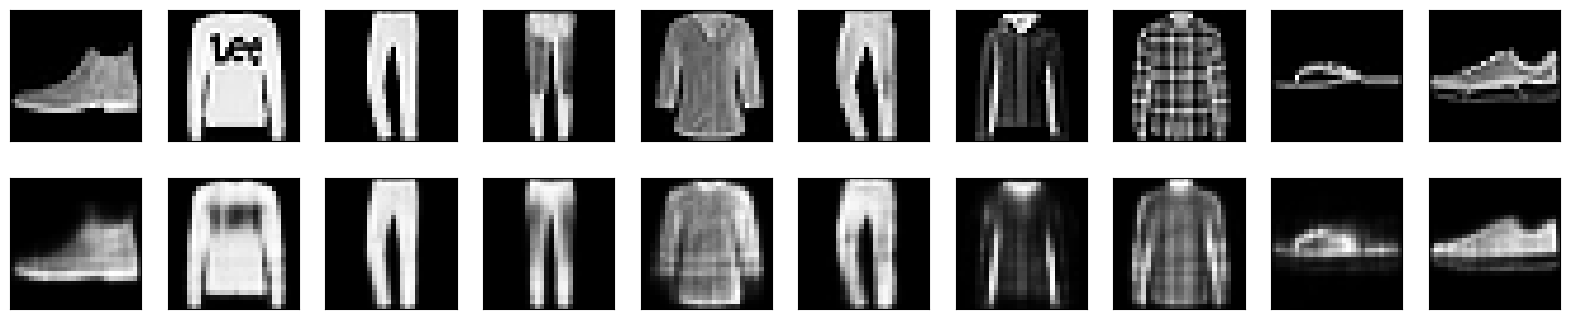

In [23]:
# Encode and decode some images

# Plot original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()